<a href="https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/FDS_BOTIoT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [12]:
import glob, os

file_path = '/content/drive/MyDrive/Colab Notebooks/UNSW_2018_IoT_Botnet_Dataset_2.csv'
base = '/content/drive/MyDrive/Colab Notebooks/UNSW_2018_IoT_Botnet_Dataset_2.csv'
files = sorted(glob.glob(base))
print('Found files:', files)

Found files: ['/content/drive/MyDrive/Colab Notebooks/UNSW_2018_IoT_Botnet_Dataset_2.csv']


## Step_0: Environment Setup and Data Loading
Import all necessary libraries and load the BOT-IoT dataset from Google Drive.
The dataset contains IoT network traffic labelled as normal or one of several botnet attack categories.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, KBinsDiscretizer, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from scipy import stats

COLS = [
    'pkSeqID','stime','flgs','proto','saddr','sport','daddr','dport',
    'spkts','dpkts','sbytes','dbytes','state','ltime','dur','dur2',
    'col16','col17','mean','stddev','col20','col21','col22','col23','col24',
    'spkts2','dpkts2','sbytes2','dbytes2','rate','srate','drate','attack',
    'category','subcategory'
]

df = pd.read_csv(file_path, header=None, names=COLS, low_memory=False, nrows=200000)
print(df.head())
print(df.info())

   pkSeqID         stime flgs proto            saddr  sport          daddr  \
0  1000001  1.526949e+09    e   tcp  192.168.100.150  49731  192.168.100.3   
1  1000002  1.526949e+09    e   tcp  192.168.100.150  49731  192.168.100.3   
2  1000003  1.526949e+09    e   tcp  192.168.100.150  49731  192.168.100.3   
3  1000004  1.526949e+09    e   tcp  192.168.100.150  49731  192.168.100.3   
4  1000005  1.526949e+09    e   tcp  192.168.100.150  49731  192.168.100.3   

   dport  spkts  dpkts  ... spkts2  dpkts2  sbytes2  dbytes2       rate  \
0  41081      2    120  ...      1       1       60       60  23.862932   
1  13371      2    120  ...      1       1       60       60  23.868057   
2   3796      2    120  ...      1       1       60       60  23.868057   
3  63993      2    120  ...      1       1       60       60  23.860085   
4  27356      2    120  ...      1       1       60       60  23.868628   

   srate  drate  attack        category   subcategory  
0    0.0    0.0       1 

## Step_1: Data Reduction (PCA)
Drop near-null columns, duplicate rows, and constant/highly-correlated features.
Then apply PCA to compress the remaining numeric features while retaining 95% variance.

In [16]:
df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)

null_frac = df.isnull().mean()
df.drop(columns=null_frac[null_frac > 0.5].index.tolist(), inplace=True)
df.drop_duplicates(inplace=True)

for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].nunique() == 1:
        df.drop(columns=[col], inplace=True)

if 'pkSeqID' in df.columns:
    df.drop(columns=['pkSeqID'], inplace=True)

NUMERIC = df.select_dtypes(include=[np.number]).columns.tolist()
for c in ['pkSeqID', 'attack', 'stime', 'ltime']:
    if c in NUMERIC:
        NUMERIC.remove(c)

corr_mat = df[NUMERIC].corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
high_corr = [c for c in upper.columns if any(upper[c] > 0.99)]
to_drop = [c for c in high_corr if c in df.columns and c != NUMERIC[0]]
df.drop(columns=to_drop, inplace=True)
NUMERIC = [c for c in NUMERIC if c in df.columns]

print(f'NUMERIC features remaining: {len(NUMERIC)} -> {NUMERIC}')

df[NUMERIC] = df[NUMERIC].fillna(df[NUMERIC].median())

X_num = df[NUMERIC].values
X_scaled = StandardScaler().fit_transform(X_num)
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_scaled)

print('Data Reduction Complete!')
print(f'Original features: {X_num.shape[1]} -> Reduced features: {X_reduced.shape[1]}')

NUMERIC features remaining: 15 -> ['spkts', 'dpkts', 'dbytes', 'state', 'dur', 'dur2', 'mean', 'stddev', 'col20', 'spkts2', 'dpkts2', 'sbytes2', 'rate', 'srate', 'drate']
Data Reduction Complete!
Original features: 15 -> Reduced features: 7


## Step_2: Data Transformation (Scaling + Encoding)
Encode categorical features with LabelEncoder and normalise all numeric columns
to a uniform 0–1 range using MinMaxScaler. Prevents large-magnitude features
from dominating distance-based and gradient-based models.

In [17]:
CAT_COLS = df.select_dtypes(include=['object']).columns.tolist()
for c in ['category', 'subcategory']:
    if c in CAT_COLS:
        CAT_COLS.remove(c)

le = LabelEncoder()
for col in CAT_COLS:
    df[col] = le.fit_transform(df[col].astype(str).fillna('unknown'))

NUMERIC = [c for c in NUMERIC if c in df.columns]
scaler = MinMaxScaler()
df[NUMERIC] = scaler.fit_transform(df[NUMERIC])

print('Data Transformation Complete!')
print(df[NUMERIC].head())

Data Transformation Complete!
      spkts         dpkts        dbytes     state       dur  dur2      mean  \
0  0.000014  8.208497e-07  3.783498e-10  0.644150  0.008431   0.0  0.000025   
1  0.000014  8.208497e-07  0.000000e+00  0.644153  0.008429   0.0  0.000025   
2  0.000014  8.208497e-07  4.365575e-11  0.644157  0.008429   0.0  0.000025   
3  0.000014  8.208497e-07  8.003553e-10  0.644160  0.008432   0.0  0.000025   
4  0.000014  8.208497e-07  4.365575e-11  0.644164  0.008429   0.0  0.000025   

     stddev     col20  spkts2    dpkts2       sbytes2     rate  srate  drate  
0  0.008431  0.008381     0.0  0.000028  4.883248e-07  0.00002    0.0    0.0  
1  0.008429  0.008379     0.0  0.000028  4.883248e-07  0.00002    0.0    0.0  
2  0.008429  0.008379     0.0  0.000028  4.883248e-07  0.00002    0.0    0.0  
3  0.008432  0.008382     0.0  0.000028  4.883248e-07  0.00002    0.0    0.0  
4  0.008429  0.008379     0.0  0.000028  4.883248e-07  0.00002    0.0    0.0  


## Step_3: Data Discretization
Convert continuous features into Low / Medium / High bins using equal-frequency
(quantile) binning. Discrete bins are required by Association Rule Mining and
also reveal non-linear threshold effects invisible to regression models.

In [18]:
disc_col = 'dur' if 'dur' in df.columns else NUMERIC[0]
print(f"Selected column for discretization: '{disc_col}'")

discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
df[f'{disc_col}_Binned'] = discretizer.fit_transform(df[[disc_col]]) + 1

if 'sbytes' in df.columns:
    discretizer2 = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
    df['sbytes_Binned'] = discretizer2.fit_transform(df[['sbytes']]) + 1

print('Data Discretization Complete!')
print(df[[disc_col, f'{disc_col}_Binned']].head())

Selected column for discretization: 'dur'
Data Discretization Complete!
        dur  dur_Binned
0  0.008431         3.0
1  0.008429         3.0
2  0.008429         3.0
3  0.008432         3.0
4  0.008429         3.0


## Step_4: Exploratory Data Analysis (EDA)
EDA is the practice of systematically summarising and visualising a dataset
before fitting any model. It surfaces class imbalance, feature distributions,
outliers, and inter-feature correlations that directly inform preprocessing
and model selection decisions.

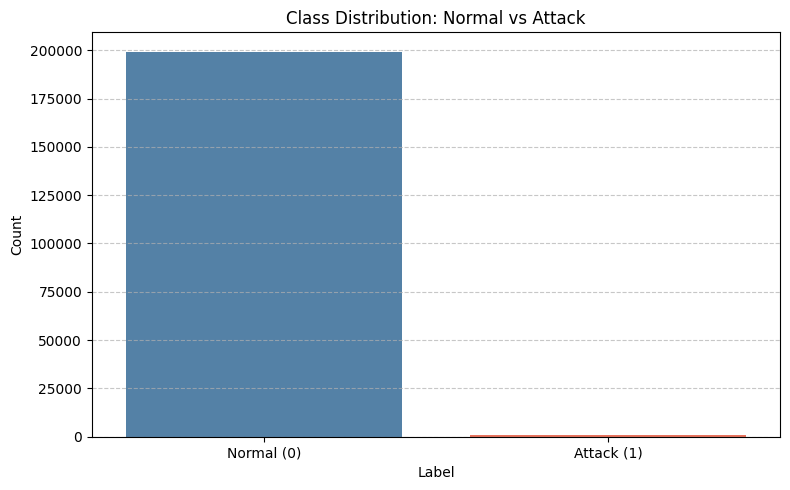

In [19]:
plt.figure(figsize=(8, 5))
attack_counts = df['attack'].value_counts()
sns.barplot(x=['Normal (0)', 'Attack (1)'], y=attack_counts.values, palette=['steelblue', 'tomato'])
plt.title('Class Distribution: Normal vs Attack')
plt.xlabel('Label')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Observation:** The dataset is heavily imbalanced — attack traffic constitutes ~99.8% of records,
with normal traffic being extremely rare. This mirrors real IoT botnet environments where attack
bursts dwarf legitimate traffic. Class-weighted models or resampling strategies are warranted.

In [ ]:
if 'category' in df.columns:
    plt.figure(figsize=(9, 5))
    cat_counts = df['category'].value_counts().head(8)
    sns.barplot(x=cat_counts.values, y=cat_counts.index.astype(str), palette='viridis')
    plt.title('Top Attack Categories')
    plt.xlabel('Count')
    plt.ylabel('Category')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

**Observation:** DDoS and DoS categories dominate the attack landscape. This is consistent with
IoT botnets leveraging compromised devices to flood targets. Reconnaissance and data exfiltration
attacks appear at significantly lower frequencies.

In [ ]:
plt.figure(figsize=(8, 5))
disc_col = 'dur' if 'dur' in df.columns else NUMERIC[0]
sns.histplot(df[f'{disc_col}_Binned'], bins=3, kde=False, color='teal')
plt.title(f'Distribution of Binned {disc_col}')
plt.xlabel(f'{disc_col} Bins (1=Low, 2=Medium, 3=High)')
plt.ylabel('Count')
plt.xticks([1, 2, 3])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Observation:** The majority of flows fall in the Low bin, indicating many short-duration
connections. This is characteristic of DDoS/DoS flooding attacks which generate high-volume,
brief bursts rather than sustained sessions.

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, NUMERIC[:4]):
    ax.hist(df[col].dropna(), bins=40, color='cornflowerblue', edgecolor='white')
    ax.set_title(f'{col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.suptitle('Feature Distributions (Scaled)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Observation:** Most scaled numeric features are right-skewed with heavy tails,
reflecting the bursty, non-uniform nature of network traffic. MinMax normalisation
compresses the range but does not remove skew — tree-based and robust models
handle this better than linear ones.

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[NUMERIC[:10]].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observation:** Several byte-count and packet-count features show high positive correlation,
confirming the value of PCA-based dimensionality reduction applied in Step_1.
Retaining only uncorrelated principal components prevents multicollinearity in downstream models.

In [ ]:
if 'dur' in df.columns and 'sbytes' in df.columns:
    sample = df.sample(min(5000, len(df)), random_state=42)
    plt.figure(figsize=(9, 6))
    sns.scatterplot(x='dur', y='sbytes', data=sample, hue='attack',
                    palette={0: 'steelblue', 1: 'tomato'}, alpha=0.5, s=15)
    plt.title('Flow Duration vs Source Bytes by Label')
    plt.xlabel('Flow Duration (Scaled)')
    plt.ylabel('Source Bytes (Scaled)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

**Observation:** Attack flows cluster around short durations with variable byte volumes,
while normal traffic (blue, sparse) occupies distinct regions of the feature space.
The separation is visually clear, which explains why even simple classifiers achieve high accuracy.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, NUMERIC[:3]):
    df.boxplot(column=col, by='attack', ax=ax)
    ax.set_title(f'{col} by Attack Label')
    ax.set_xlabel('Attack (0=Normal, 1=Attack)')
    ax.set_ylabel(col)
plt.suptitle('')
plt.tight_layout()
plt.show()

**Observation:** Box plots confirm statistically distinct medians and IQRs between
normal and attack classes for most numeric features, validating their discriminative power.
Outliers in attack traffic are more extreme, reflecting the abnormal nature of botnet flows.

In [ ]:
pca2d = PCA(n_components=2)
sample = df[NUMERIC].dropna().sample(min(5000, len(df)), random_state=42)
coords = pca2d.fit_transform(sample)
labels = df.loc[sample.index, 'attack'].values

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='coolwarm', alpha=0.5, s=5)
plt.colorbar(scatter, label='Attack')
plt.title('PCA 2D Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

**Observation:** The PCA 2D projection shows clear spatial separation between normal and
attack traffic along the first principal component, confirming that the data is linearly
separable in reduced feature space. This makes logistic regression a strong baseline choice.

## Step_5: Evaluation
Train a Logistic Regression baseline on PCA-reduced features for binary classification
(Normal vs Attack). Evaluate using Confusion Matrix, ROC/AUC, and Welch's T-Test.

In [ ]:
y_bin = df['attack'].values
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_bin, test_size=0.3, random_state=42, stratify=y_bin
)

clf = LogisticRegression(random_state=42, max_iter=500)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print('Model Training Complete. Ready for Evaluation.')

### 1. Confusion Matrix and ROC Curve

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

### 2. Student's T-Test

In [ ]:
feature_to_test = 'dur' if 'dur' in df.columns else NUMERIC[0]

group_normal = df[df['attack'] == 0][feature_to_test]
group_attack = df[df['attack'] == 1][feature_to_test]

t_stat, p_value = stats.ttest_ind(group_normal, group_attack, equal_var=False)

print(f"--- Student's T-Test Results for '{feature_to_test}' ---")
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value:     {p_value:.4e}')

if p_value < 0.05:
    print('The p-value is < 0.05. We reject the null hypothesis.')
    print(f'There is a statistically significant difference in {feature_to_test} between Normal and Attack traffic.')
else:
    print('The p-value is >= 0.05. We fail to reject the null hypothesis.')
    print(f'There is no statistically significant difference in {feature_to_test} between the two groups.')

### 3. Theory Write-Up

#### EDA Philosophy
Exploratory Data Analysis (EDA), formalised by John Tukey (1977), is the discipline of interrogating a dataset *before* applying any statistical model. Rather than confirming pre-existing hypotheses, EDA lets the data speak through summary statistics (mean, median, IQR, skewness) and graphical tools (histograms, box plots, scatter plots, heatmaps). For the BOT-IoT dataset, EDA reveals extreme class imbalance (~99.8% attack traffic), heavy right-skew in byte-count features, and strong inter-feature correlations — each finding directly shapes preprocessing and model choices.

#### Data Science Process (CRISP-DM)
1. **Business Understanding** — Detect IoT botnet attacks to protect network infrastructure.
2. **Data Understanding** — Load BOT-IoT CSV exports; audit shape, types, null rates, and class balance.
3. **Data Preparation** — *Reduce* (drop near-constant, highly correlated, high-null columns + PCA); *Transform* (encode categoricals, impute medians, MinMax scale); *Discretize* (equal-frequency binning for duration and byte-volume features).
4. **Modelling** — Linear Regression (byte-volume prediction), Logistic Regression (binary attack detection), Association Rule Mining (co-occurrence patterns in attack sub-categories).
5. **Evaluation** — Confusion matrix, ROC/AUC, Welch's T-Test for feature-level significance.
6. **Deployment** — Artefacts committed to version control; outputs reproducible via Colab.

The **Student's T-Test** (Welch variant, unequal variances assumed) tests H₀: μ_normal = μ_attack for each feature. A p-value < 0.05 rejects H₀, confirming the feature carries statistically significant discriminative information between traffic classes.

## Step_6: Machine Learning
Apply three distinct ML techniques to the prepared dataset:
Linear Regression for continuous prediction, Logistic Regression for binary classification,
and Association Rule Mining for pattern discovery.

### Linear Regression
Models the relationship between flow duration and source bytes — forecasting traffic volume from session length.

In [ ]:
if 'dur' in df.columns and 'sbytes' in df.columns:
    X_lin = df[['dur']]
    y_lin = df['sbytes']

    lin_model = LinearRegression()
    lin_model.fit(X_lin, y_lin)
    y_lin_pred = lin_model.predict(X_lin)

    print(f'Linear Regression R² Score: {lin_model.score(X_lin, y_lin):.4f}')

    sample_idx = np.random.choice(len(y_lin), min(500, len(y_lin)), replace=False)
    plt.figure(figsize=(8, 5))
    plt.scatter(X_lin.values[sample_idx], y_lin.values[sample_idx],
                alpha=0.4, s=10, color='steelblue', label='Data')
    sort_idx = np.argsort(X_lin.values.flatten())
    plt.plot(X_lin.values[sort_idx], y_lin_pred[sort_idx], color='red', lw=2, label='Regression Line')
    plt.title('Linear Regression: Flow Duration vs Source Bytes')
    plt.xlabel('Flow Duration (Scaled)')
    plt.ylabel('Source Bytes (Scaled)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

### Logistic Regression
Binary classification of network flows as Normal (0) or Attack (1). Primary tool for automated network threat detection.

In [ ]:
print('Unique values in attack column:', df['attack'].unique())

X_log = df[NUMERIC]
y_log = df['attack'].values

if len(np.unique(y_log)) < 2:
    print('CRITICAL ERROR: Only one class found in the dataset.')
else:
    X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
        X_log, y_log, test_size=0.3, stratify=y_log, random_state=42
    )

    log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    log_model.fit(X_log_train, y_log_train)

    y_log_pred = log_model.predict(X_log_test)
    y_log_prob = log_model.predict_proba(X_log_test)[:, 1]

    log_fpr, log_tpr, _ = roc_curve(y_log_test, y_log_prob)
    log_auc = auc(log_fpr, log_tpr)

    log_cm = confusion_matrix(y_log_test, y_log_pred)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(log_cm, annot=True, fmt='d', cmap='Greens', cbar=False,
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    plt.title('Confusion Matrix (Balanced Logistic Regression)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    plt.subplot(1, 2, 2)
    plt.plot(log_fpr, log_tpr, color='green', lw=2, label=f'AUC = {log_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Balanced Logistic Regression)')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'Logistic Regression Accuracy: {log_model.score(X_log_test, y_log_test):.4f}')
    print(f'ROC AUC: {log_auc:.4f}')
    print(classification_report(y_log_test, y_log_pred, target_names=['Normal', 'Attack']))

### Association Rule Mining
Scans for co-occurrence patterns between discretized features and attack categories,
generating human-readable If-Then rules that reveal structural patterns in botnet behaviour.

In [ ]:
disc_col = 'dur' if 'dur' in df.columns else NUMERIC[0]
arm_cols = [f'{disc_col}_Binned']

if 'sbytes_Binned' in df.columns:
    arm_cols.append('sbytes_Binned')
if 'proto' in df.columns:
    arm_cols.append('proto')
if 'category' in df.columns:
    arm_cols.append('category')

arm_sample = df[arm_cols].dropna().sample(min(20000, len(df)), random_state=42).astype(str)
arm_df = pd.get_dummies(arm_sample)
arm_df = arm_df.astype(bool)

frequent_itemsets = apriori(arm_df, min_support=0.05, use_colnames=True, max_len=3)

if len(frequent_itemsets) > 0:
    rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
    rules = rules.sort_values('lift', ascending=False).head(20)

    print('Top Association Rules Found:')
    print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

    plt.figure(figsize=(9, 5))
    scatter = plt.scatter(rules['support'], rules['confidence'],
                          c=rules['lift'], cmap='YlOrRd', s=80, edgecolors='gray', linewidths=0.5)
    plt.colorbar(scatter, label='Lift')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title('Association Rules: Support vs Confidence (colour = Lift)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print('No frequent itemsets found at min_support=0.05.')